In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import construction_helpers as ch # Needed for @ auto-alignment
import data_structure.Category as cat
import data_structure.Numeric as nm
import data_structure.Operators as ops
import data_structure.Term as fd
import websocket_transfer.capture as cap

Requesting render from server...
Received from server: {"msgType": "Connected"}


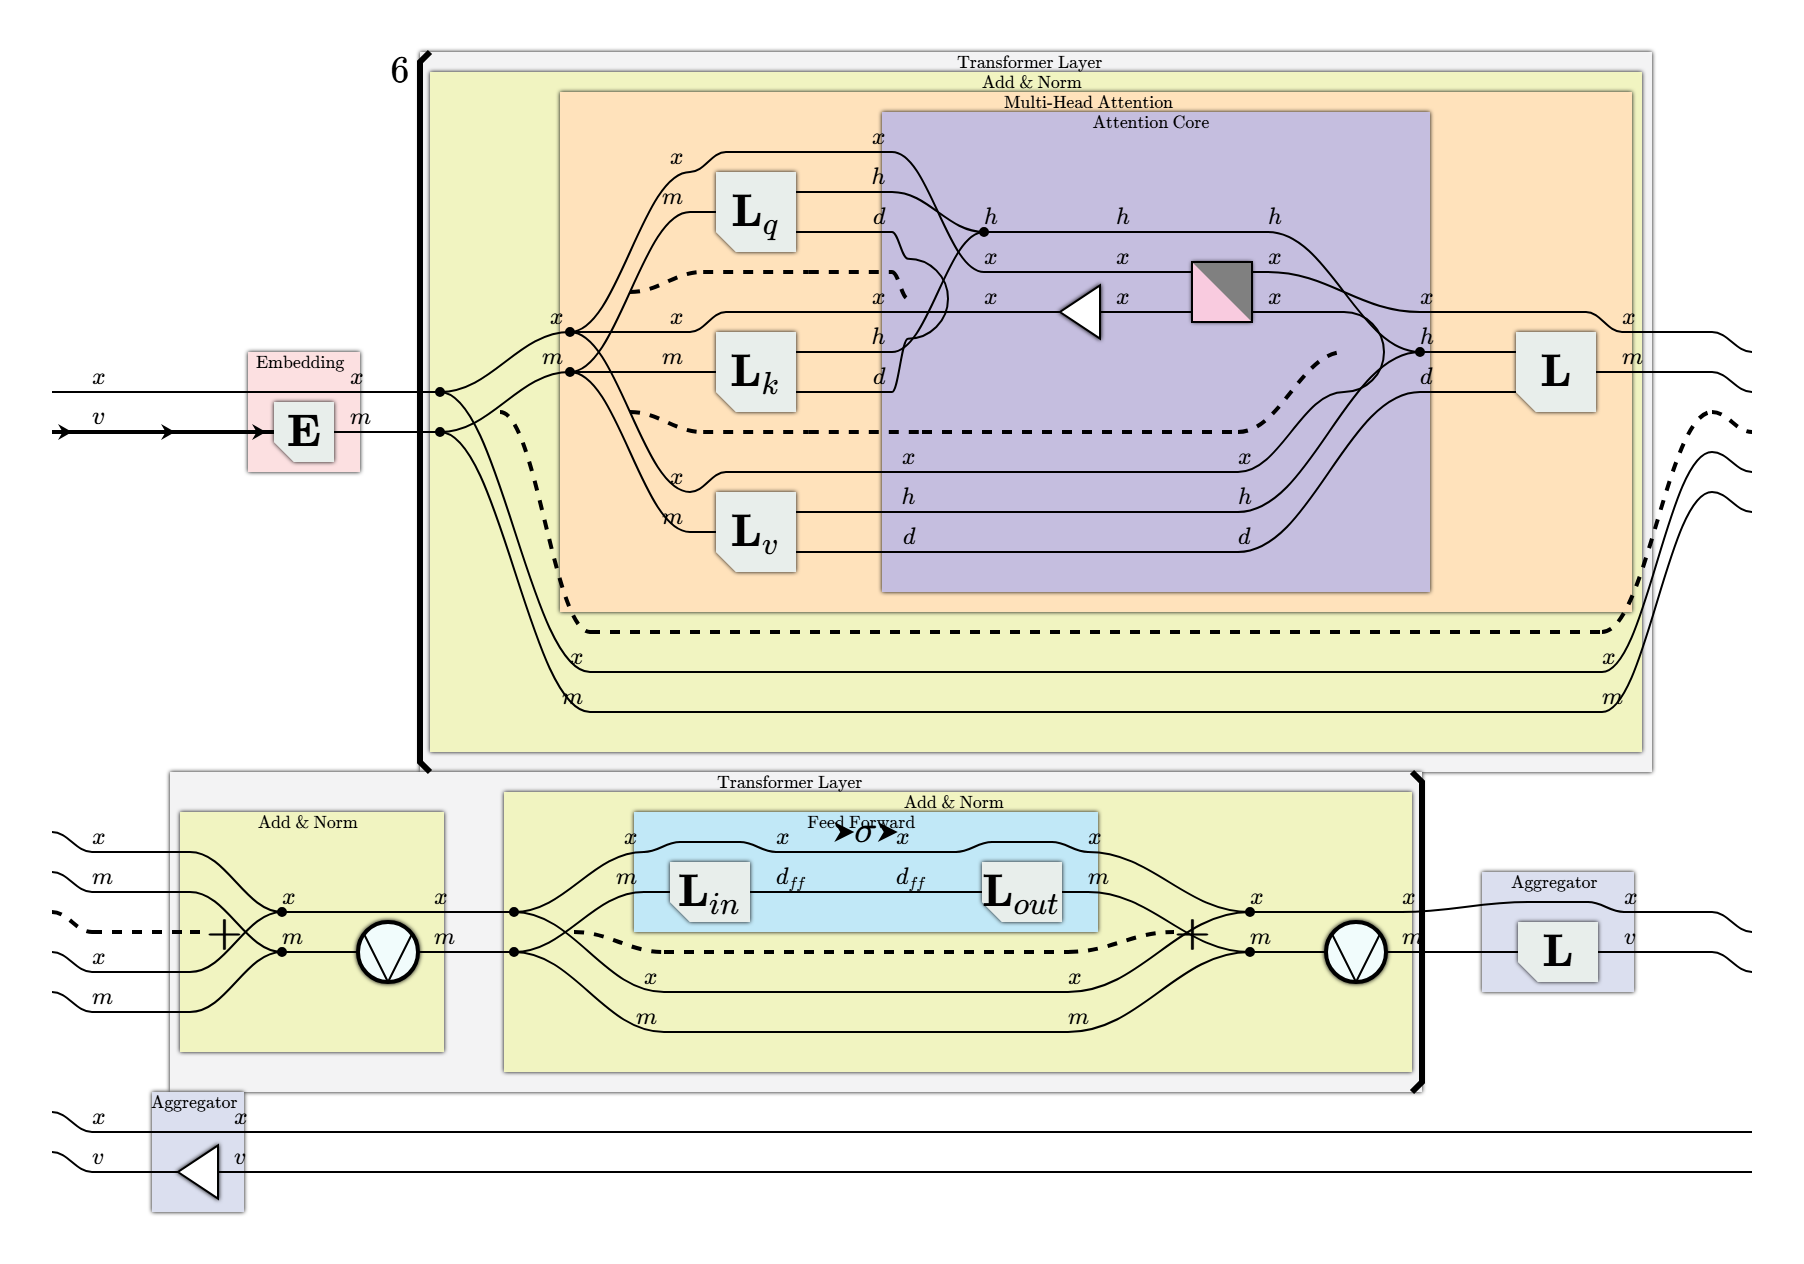

In [3]:
mh_attention = cat.Block.template(
      ops.Einops.template('q h d, x h d -> h q x')
    @ ops.SoftMax.template()
    @ ops.WeightedTriangularLower.template()
    @ ops.Einops.template('h q x, x h d -> q h d'),
    title='Attention Core',
    fill_color='#C5BEDF'
)
attention_block = cat.Block.template(
    (0, 0, 0) 
    @(ops.Linear.template('m', 2, 'L_q')
    * ops.Linear.template('m', 2, 'L_k')
    * ops.Linear.template('m', 2, 'L_v'))
    @ mh_attention
    @ ops.Linear.template(2, 'm'),
    title = 'Multi-Head Attention', fill_color='#FFE2BB'
)
ffn = cat.Block.template(
    ops.Linear.template(1, ('d_ff',), 'L_in') 
    @ ops.Elementwise.template() 
    @ ops.Linear.template(('d_ff',), 1, 'L_out'),
    title='Feed Forward', fill_color='#C1E8F7'
)
embedding = cat.Block.template(
    ops.Embedding.template('v'),
    title='Embedding', fill_color='#FCE0E1'
)
aggregator = cat.Block.template(
    ops.Linear.template(1, 'v')
    @ ops.SoftMax.template(),
    title='Aggregator', fill_color='#DBDFEF'
)
def resnet(target):
    return cat.Block.template(
          (0, 0)
        @ target
        @ ops.AdditionOp.template()
        @ ops.Normalize.template(),
        title='Add \\& Norm', fill_color='#F1F4C1'
    )
transformer = (
    embedding
    @ cat.Block.template(
        resnet(attention_block)
        @ resnet(ffn),
        repetition=6,
        title='Transformer Layer', fill_color='#F3F3F4'
    )
    @ aggregator
)
await cap.capture_morphism(transformer)